In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer,MinMaxScaler

In [3]:
train=pd.read_csv('/kaggle/input/titanic/train.csv',index_col='PassengerId')
test=pd.read_csv('/kaggle/input/titanic/test.csv',index_col='PassengerId')
submit=pd.DataFrame(test.index)
xtrain,xvalid,ytrain,yvalid=train_test_split(train,train['Survived'],test_size=0.22,random_state=42)

In [4]:
xtrain['title']=0
for i in range(len(xtrain)):
    xtrain['title'].iloc[i]=xtrain['Name'].iloc[i].split(',')[1].split('.')[0][1:]
xtrain['title']=xtrain['title'].replace(['Mme','Major','Mlle','Col','the Countess','Jonkheer','Don'],'Rare')
xtrain['title']=xtrain['title'].replace({'Mr':1,'Miss':2,'Mrs':3,'Rare':5,'Rev':6,'Dr':7,'Lady':2,'Capt':5,'Master':4,'Ms':2})  

xvalid['title']=0
for i in range(len(xvalid)):
    xvalid['title'].iloc[i]=xvalid['Name'].iloc[i].split(',')[1].split('.')[0][1:]
xvalid['title']=xvalid['title'].replace(['Mme','Major','Mlle','Col','the Countess','Jonkheer','Don','Sir'],'Rare')
xvalid['title']=xvalid['title'].replace({'Mr':1,'Miss':2,'Mrs':3,'Rare':5,'Rev':6,'Dr':7,'Lady':2,'Capt':5,'Master':4,'Ms':2})  


xtrain['passenger']=xtrain['SibSp']+xtrain['Parch']+1
xvalid['passenger']=xvalid['SibSp']+xvalid['Parch']+1

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.
/opt/conda/lib/python3.7/site-packages/pandas/core/indexing.py:1637: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
/opt/conda/lib/python3.7/site-packages/pandas/core/indexing.py:692: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user

In [5]:
def family(size):
    a=''
    if(size<=1):
        a=1
    elif(size<=2):
        a=2
    elif(size<=4):
        a=3
    elif(size<=6):
        a=4
    else:
        a=5
    return a
xtrain['family']=xtrain['passenger'].map(family)
xvalid['family']=xvalid['passenger'].map(family)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  from ipykernel import kernelapp as app


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


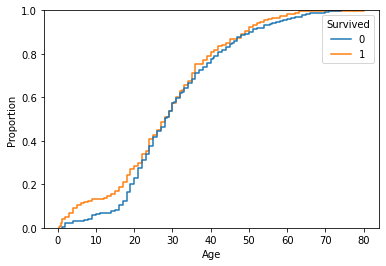

In [6]:
sns.ecdfplot(x='Age',hue='Survived',data=train)
def age_group(age):
    a=''
    if(age<=2):
        a=1
    elif(age<=7):
        a=2
    elif(age<=16):
        a=3
    elif(age<=33):
        a=4
    elif(age<=55):
        a=5
    elif(age<=70):
        a=6
    else:
        a=7
    return a
xtrain['age_group']=xtrain['Age'].map(age_group)
xvalid['age_group']=xvalid['Age'].map(age_group)

In [7]:
xtrain['Sex'].replace({'male':0,'female':1},inplace=True)
xvalid['Sex'].replace({'male':0,'female':1},inplace=True)




/opt/conda/lib/python3.7/site-packages/pandas/core/series.py:4515: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  method=method,


In [8]:
for i in range(len(xtrain)):
    if not(pd.isnull(xtrain['Cabin'].iloc[i])):
        xtrain['Cabin'].iloc[i]=xtrain['Cabin'].iloc[i][0]

for i in range(len(xvalid)):
    if not(pd.isnull(xvalid['Cabin'].iloc[i])):
        xvalid['Cabin'].iloc[i]=xvalid['Cabin'].iloc[i][0]

xtrain.drop(['Name','Ticket','Cabin'],axis=1,inplace=True)
xvalid.drop(['Name','Ticket','Cabin'],axis=1,inplace=True)

xtrain['Embarked'].replace({'S':1,'C':2,'Q':3},inplace=True)
xvalid['Embarked'].replace({'S':1,'C':2,'Q':3},inplace=True)



/opt/conda/lib/python3.7/site-packages/pandas/core/indexing.py:1637: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
/opt/conda/lib/python3.7/site-packages/pandas/core/indexing.py:692: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iloc._setitem_with_indexer(indexer, value, self.name)
/opt/conda/lib/python3.7/site-packages/pandas/core/frame.py:4315: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-co

# Data preprocessing and manupulation

<AxesSubplot:>

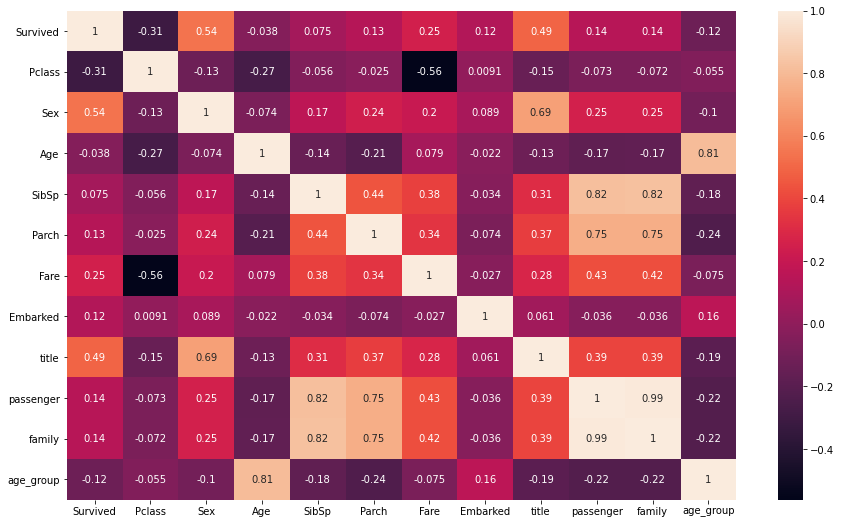

In [9]:
plt.figure(figsize=(15,9))
sns.heatmap(xtrain.corr('kendall'),annot=True)

In [10]:
xtrain['Age']=xtrain['Age'].fillna(xtrain.groupby('Pclass')['Age'].transform('mean'))
xvalid['Age']=xvalid['Age'].fillna(xvalid.groupby('Pclass')['Age'].transform('mean'))

xtrain['Embarked']=xtrain['Embarked'].fillna(1)
xvalid['Embarked']=xvalid['Embarked'].fillna(1)


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documen

In [11]:
xtrain['Fare']=np.sqrt(xtrain['Fare'])
xvalid['Fare']=np.sqrt(xvalid['Fare'])
xtrain.drop('Survived',axis=1,inplace=True)
xvalid.drop('Survived',axis=1,inplace=True)





/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score,RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest,mutual_info_classif
from sklearn.decomposition import PCA

/opt/conda/lib/python3.7/site-packages/pandas/core/frame.py:4315: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


<AxesSubplot:>

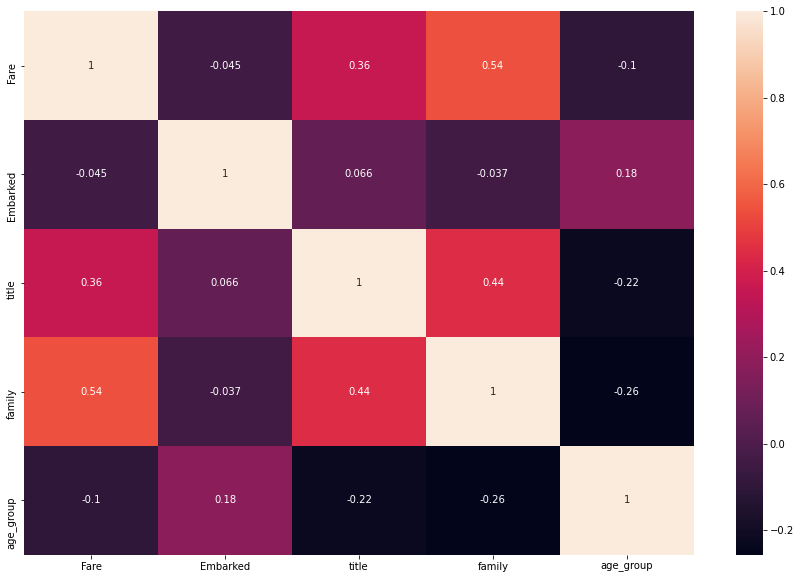

In [13]:
xtrain.drop(['passenger','Age','SibSp','Parch','Sex','Pclass'],axis=1,inplace=True)
xvalid.drop(['passenger','Age','SibSp','Parch','Sex','Pclass'],axis=1,inplace=True)
plt.figure(figsize=(15,10))
sns.heatmap(xtrain.corr('spearman'),annot=True)

In [14]:
model={'LDA':LinearDiscriminantAnalysis(),'DTC':DecisionTreeClassifier(),'SVC':SVC(),'NB':GaussianNB(),'Gbc':GradientBoostingClassifier(),'forest':GradientBoostingClassifier()}

In [15]:
cv=RepeatedStratifiedKFold(n_splits=10,n_repeats=3,random_state=43)
scores=[]
for model1 in model.keys():
    score=cross_val_score(model[model1],xtrain,ytrain,cv=cv,scoring='accuracy',n_jobs=-1)
    model[model1].fit(xtrain,ytrain)
    ypred=model[model1].predict(xvalid)
    scores.append((model1,np.mean(score),accuracy_score(yvalid,ypred)))
scores

[('LDA', 0.7328709454796412, 0.7208121827411168),
 ('DTC', 0.8006970324361629, 0.8223350253807107),
 ('SVC', 0.8045134575569359, 0.7918781725888325),
 ('NB', 0.7238026224982747, 0.7055837563451777),
 ('Gbc', 0.8223602484472051, 0.8375634517766497),
 ('forest', 0.8223533471359558, 0.8426395939086294)]

**Gradient boosting classifier**

In [16]:
parameters = {
    "n_estimators":[5,50,250,500],
    "max_depth":[1,3,5,7,9],
    "learning_rate":[0.01,0.1,1,10,100]
}
from sklearn.model_selection import GridSearchCV
cv = GridSearchCV(GradientBoostingClassifier(),parameters,cv=9)
cv.fit(xtrain,ytrain)

GridSearchCV(cv=9, estimator=GradientBoostingClassifier(),
             param_grid={'learning_rate': [0.01, 0.1, 1, 10, 100],
                         'max_depth': [1, 3, 5, 7, 9],
                         'n_estimators': [5, 50, 250, 500]})

In [17]:
max_depth=[2, 8, 16]
n_estimators = [64, 128, 256]
param_grid = dict(max_depth=max_depth, n_estimators=n_estimators)

# Build the grid search
dfrst = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth)
grid = GridSearchCV(estimator=dfrst, param_grid=param_grid, cv =9)
grid_results = grid.fit(xtrain, ytrain)
grid_results

GridSearchCV(cv=9,
             estimator=RandomForestClassifier(max_depth=[2, 8, 16],
                                              n_estimators=[64, 128, 256]),
             param_grid={'max_depth': [2, 8, 16],
                         'n_estimators': [64, 128, 256]})

# Test

In [18]:
test['title']=0
for i in range(len(test)):
    test['title'].iloc[i]=test['Name'].iloc[i].split(',')[1].split('.')[0][1:]
test['title']=test['title'].replace(['Mme','Major','Mlle','Col','the Countess','Jonkheer','Don','Dona'],'Rare')
test['title']=test['title'].replace({'Mr':1,'Miss':2,'Mrs':3,'Rare':5,'Rev':6,'Dr':7,'Lady':2,'Capt':5,'Master':4,'Ms':2})  

test['passenger']=test['SibSp']+test['Parch']+1
test['family']=test['passenger'].map(family)
test['age_group']=test['Age'].map(age_group)
test['Sex'].replace({'male':0,'female':1},inplace=True)


for i in range(len(test)):
    if not(pd.isnull(test['Cabin'].iloc[i])):
        test['Cabin'].iloc[i]=test['Cabin'].iloc[i][0]

test.drop(['Name','Ticket','Cabin'],axis=1,inplace=True)


test['Embarked'].replace({'S':1,'C':2,'Q':3},inplace=True)
test['Age']=test['Age'].fillna(test.groupby('Pclass')['Age'].transform('mean'))
test['Fare']=test['Fare'].fillna(test['Fare'].median())

test['Embarked']=test['Embarked'].fillna(1)
test['Fare']=np.sqrt(test['Fare'])

/opt/conda/lib/python3.7/site-packages/pandas/core/indexing.py:1637: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)


In [19]:
test.drop(['passenger','Age','SibSp','Parch','Sex','Pclass'],axis=1,inplace=True)
pred=cv.predict(test)
#--------------------------------------------------
submit['Survived']=pred
submit.to_csv('index.csv',index=False)

In [20]:
submit

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


###### 